In [2]:
import pandas as pd
import matplotlib.pyplot  as plt
import numpy              as np
import plotly.express       as px
import pydotplus         as pdp
import seaborn as sns

from sklearn import tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics          import mean_absolute_error, mean_squared_error
from IPython.display         import Image
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics          import accuracy_score, confusion_matrix
from sklearn.metrics          import auc,roc_curve
from sklearn.metrics          import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV


### CONCAT

In [3]:
df3 = pd.read_csv('paris_weekdays.csv')
df4 = pd.read_csv('paris_weekends.csv')

In [4]:
df3['weekends'] = 0
df4['weekends'] = 1

In [6]:
d = [df3, df4]
df = pd.concat(d, axis= 0)
df = df.rename(columns= {df.columns[0]: 'ID'})
df.drop(['ID', 'attr_index_norm', 'rest_index_norm'], axis=1, inplace=True)
df

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,lng,lat,weekends
0,296.159940,Private room,False,True,2.0,True,0,0,10.0,97.0,1,0.699821,0.193709,518.478947,1218.662228,2.35385,48.86282,0
1,288.237487,Private room,False,True,2.0,True,0,0,10.0,97.0,1,2.100005,0.107221,873.216962,1000.543327,2.32436,48.85902,0
2,211.343089,Private room,False,True,2.0,False,0,0,10.0,94.0,1,3.302325,0.234724,444.556077,902.854467,2.31714,48.87475,0
3,298.956100,Entire home/apt,False,False,2.0,False,0,1,9.0,91.0,1,0.547567,0.195997,542.142014,1199.184166,2.35600,48.86100,0
4,247.926181,Entire home/apt,False,False,4.0,False,0,0,7.0,82.0,1,1.197921,0.103573,406.928958,1070.775497,2.35915,48.86648,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,295.460900,Entire home/apt,False,False,4.0,False,0,0,9.0,80.0,1,3.660389,0.168146,209.752453,540.326583,2.38051,48.88393,1
3554,232.081275,Entire home/apt,False,False,4.0,False,0,0,10.0,98.0,1,3.558813,0.154703,185.486701,474.351813,2.40050,48.85093,1
3555,223.925809,Entire home/apt,False,False,2.0,False,1,0,9.0,89.0,1,4.205205,0.253029,172.658919,406.585935,2.40100,48.87700,1
3556,200.857489,Entire home/apt,False,False,2.0,True,0,0,9.0,93.0,1,2.891214,0.240674,235.167925,602.451672,2.38200,48.87400,1


In [7]:
df.isnull().sum()

realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index                    0
rest_index                    0
lng                           0
lat                           0
weekends                      0
dtype: int64

### EDA


In [8]:
continuous_cols = ['realSum', 'guest_satisfaction_overall', 
                 'dist','metro_dist', 'attr_index','rest_index', 'lng', 'lat']
discrete_cols = ['person_capacity', 'cleanliness_rating', 'bedrooms' ]
binary_cols = ['room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz', 'weekends']
nominal_cols = ['room_type']

In [ ]:
nrows = 8
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 15))
axes = axes.flatten()


for i, col in enumerate(continuous_cols):
    base = i*2

    ax = axes[base]
    ax.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    ax.set_title(col, fontsize= 9)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    ax = axes[base+1]
    ax.boxplot(df[col], vert=False)
    ax.set_title(col, fontsize= 9)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('Phân phối các biến liên tục', weight= 'bold')
plt.tight_layout()
plt.show()

In [ ]:
nrows = 1
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='skyblue', edgecolor='black', width=0.7)
    ax.set_title(col, fontsize=9)
    
    ax.set_xticks(counts.index)

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.locator_params(axis='x', nbins=len(counts))

for k in range(len(discrete_cols), len(axes)):
    fig.delaxes(axes[k])
fig.suptitle('Phân phối các biến rời rạc', weight='bold')
plt.tight_layout()
plt.show()


In [ ]:
df[binary_cols]

In [ ]:
nrows = 2
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 5))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    ax = axes[i]
    freq = df[col].value_counts()
    labels = freq.index.astype(str)
    sizes = freq.values

    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',      
        startangle=90,
        colors=['#66b3ff', "#2F13E1"],  
        wedgeprops={'edgecolor': 'black'}
    )
    ax.set_title(col, fontsize=9)


for k in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Phân phối các biến nhị phân', weight='bold')
plt.tight_layout()
plt.show()


In [ ]:
nrows = 1
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 4))
axes = axes.flatten()


for i, col in enumerate(nominal_cols):
    ax = axes[i]
    freq = df[col].value_counts()
    ax.bar(freq.index.astype(str), freq.values, color='skyblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

for k in range(len(nominal_cols), len(axes)):
    fig.delaxes(axes[k])

plt.title(f'Phân phối biến {col} ', weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
num_cols = continuous_cols + discrete_cols
num_mtrx = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    num_mtrx,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)

### PREPROCESSING

#### Phân lớp

In [59]:
df_clf = df.copy()

In [85]:
# LOẠI realSum > 4000
#df_clf = df_clf.loc[df_clf['realSum'] <= 4000, :]

In [27]:
#sns.boxplot(df_clf['realSum'])
#df_clf['realSum'].hist()

In [60]:
# Tính trung vị của giá
median_price = df_clf['realSum'].median()

# Hàm phân loại 2 nhóm giá
def classify_price(x):
    if x <= median_price:
        return 'Thấp'
    else:
        return 'Cao'

# Tạo cột nhãn
df_clf['price_group'] = df_clf['realSum'].apply(classify_price)


In [61]:
# Tạo biến x, y, z từ lat và lng
df_clf['x'] = np.cos(np.radians(df_clf['lat'])) * np.cos(np.radians(df_clf['lng']))
df_clf['y'] = np.cos(np.radians(df_clf['lat'])) * np.sin(np.radians(df_clf['lng']))
df_clf['z'] = np.sin(np.radians(df_clf['lat']))

In [62]:
# Xoá cột lat, lng 
df_clf = df_clf.drop(['lng', 'lat'], axis=1)

In [64]:
# Loại bỏ lat và lng khỏi danh sách 
continuous_cols = [c for c in continuous_cols if c not in ['lat', 'lng']]

# Tạo features hợp lệ
features = continuous_cols + discrete_cols + binary_cols + nominal_cols

# Lấy X và y
X = df_clf[features]
y = df_clf['price_group']


In [65]:
# Chia train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [81]:
# Huấn luyện lại mô hình
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [83]:
# Dự đoán trên tập huấn luyện và tập kiểm tra
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Đánh giá trên tập huấn luyện
print("===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====")
print("Accuracy (Train):", accuracy_score(y_train, y_train_pred))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_pred))

# Đánh giá trên tập kiểm tra
print("\n===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====")
print("Accuracy (Test):", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====
Accuracy (Train): 1.0

Classification Report (Train):
               precision    recall  f1-score   support

         Cao       1.00      1.00      1.00      2338
        Thấp       1.00      1.00      1.00      2343

    accuracy                           1.00      4681
   macro avg       1.00      1.00      1.00      4681
weighted avg       1.00      1.00      1.00      4681


===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====
Accuracy (Test): 0.85401096163428

Classification Report (Test):
               precision    recall  f1-score   support

         Cao       0.84      0.87      0.86      1002
        Thấp       0.87      0.84      0.85      1005

    accuracy                           0.85      2007
   macro avg       0.85      0.85      0.85      2007
weighted avg       0.85      0.85      0.85      2007



In [84]:
# Tạo tập dữ liệu
# -----------------------------
X = df_clf.drop(['realSum', 'price_group'], axis=1)
y = df_clf['price_group']

In [85]:
# Chia train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [90]:
# Tiền xử lý biến lệch phải (log-transform)
# -----------------------------
cols_skewed = ['dist', 'metro_dist', 'attr_index', 'rest_index']
for col in cols_skewed:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

In [91]:
# Tìm tham số tốt nhất cho CART
# -----------------------------
param_grid = {
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 20, 30],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Cross-validation accuracy:", round(grid_search.best_score_, 3))

Best parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}
Cross-validation accuracy: 0.79


In [92]:
# Huấn luyện CART với tham số tối ưu
# -----------------------------
best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [93]:
# Đánh giá mô hình
# -----------------------------
y_pred = best_clf.predict(X_test)
y_test_pred = best_clf.predict(X_test)

# HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN
# =============================
print("===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====")
print("Accuracy (Train):", round(accuracy_score(y_train, y_train_pred), 3))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix (Train):\n", confusion_matrix(y_train, y_train_pred))

# =============================
# HIỆU SUẤT TRÊN TẬP KIỂM TRA
# =============================
print("\n===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====")
print("Accuracy (Test):", round(accuracy_score(y_test, y_test_pred), 3))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))

===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====
Accuracy (Train): 1.0

Classification Report (Train):
               precision    recall  f1-score   support

         Cao       1.00      1.00      1.00      2338
        Thấp       1.00      1.00      1.00      2343

    accuracy                           1.00      4681
   macro avg       1.00      1.00      1.00      4681
weighted avg       1.00      1.00      1.00      4681

Confusion Matrix (Train):
 [[2338    0]
 [   0 2343]]

===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====
Accuracy (Test): 0.807

Classification Report (Test):
               precision    recall  f1-score   support

         Cao       0.80      0.82      0.81      1002
        Thấp       0.82      0.80      0.81      1005

    accuracy                           0.81      2007
   macro avg       0.81      0.81      0.81      2007
weighted avg       0.81      0.81      0.81      2007

Confusion Matrix (Test):
 [[821 181]
 [206 799]]


In [94]:
# Lấy giá trị alpha có thể tỉa
path = best_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # bỏ alpha cuối vì sẽ tỉa toàn bộ cây

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        criterion=grid_search.best_params_['criterion'],
        class_weight=grid_search.best_params_['class_weight'],
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))


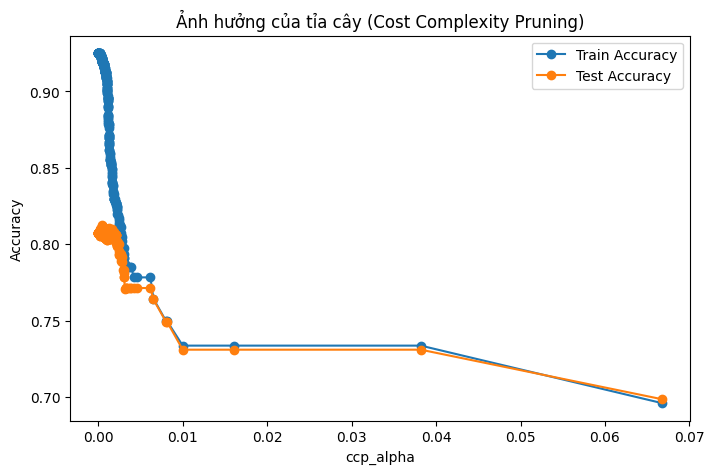

In [95]:
# Vẽ biểu đồ độ chính xác theo ccp_alpha
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Ảnh hưởng của tỉa cây (Cost Complexity Pruning)')
plt.legend()
plt.show()

In [96]:
# Chọn alpha tốt nhất (max test accuracy)
best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Best ccp_alpha:", round(best_alpha, 5))

Best ccp_alpha: 0.0005


In [97]:
# Huấn luyện lại mô hình với alpha tối ưu
pruned_clf = DecisionTreeClassifier(
    random_state=42,
    criterion=grid_search.best_params_['criterion'],
    class_weight=grid_search.best_params_['class_weight'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    ccp_alpha=best_alpha
)
pruned_clf.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [ ]:
# Đánh giá lại
y_train_pred_pruned = pruned_clf.predict(X_train)
y_test_pred_pruned = pruned_clf.predict(X_test)

# HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN
# =============================
print("===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (PRUNED TREE) =====")
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred_pruned), 3))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_pred_pruned))
print("Confusion Matrix (Train):\n", confusion_matrix(y_train, y_train_pred_pruned))

# =============================
# HIỆU SUẤT TRÊN TẬP KIỂM TRA
# =============================
print("\n===== HIỆU SUẤT TRÊN TẬP KIỂM TRA (PRUNED TREE) =====")
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred_pruned), 3))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred_pruned))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred_pruned))

===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (PRUNED TREE) =====
✅ Train Accuracy: 0.92

Classification Report (Train):
               precision    recall  f1-score   support

         Cao       0.91      0.93      0.92      2338
        Thấp       0.93      0.91      0.92      2343

    accuracy                           0.92      4681
   macro avg       0.92      0.92      0.92      4681
weighted avg       0.92      0.92      0.92      4681

Confusion Matrix (Train):
 [[2167  171]
 [ 203 2140]]

===== HIỆU SUẤT TRÊN TẬP KIỂM TRA (PRUNED TREE) =====
✅ Test Accuracy: 0.813

Classification Report (Test):
               precision    recall  f1-score   support

         Cao       0.80      0.83      0.82      1002
        Thấp       0.82      0.80      0.81      1005

    accuracy                           0.81      2007
   macro avg       0.81      0.81      0.81      2007
weighted avg       0.81      0.81      0.81      2007

Confusion Matrix (Test):
 [[829 173]
 [203 802]]


In [100]:
# Trước khi tỉa
print("Before pruning:")
print("Tree depth:", best_clf.get_depth())
print("Number of leaves:", best_clf.get_n_leaves())

# Sau khi tỉa
print("\nAfter pruning:")
print("Tree depth:", pruned_clf.get_depth())
print("Number of leaves:", pruned_clf.get_n_leaves())


Before pruning:
Tree depth: 20
Number of leaves: 408

After pruning:
Tree depth: 20
Number of leaves: 355


KHÚC SAU LÀ QUỲNH LÀM Á, NÊN CHỊ CHƯA XÓA

In [51]:

# --- 1. Chuẩn bị dữ liệu ---
X = df_clf.drop(['realSum', 'price_group'], axis=1)
y = df_clf['price_group']

# One-hot cho room_type
X = pd.get_dummies(X, columns=['room_type'], drop_first=True)

# --- 2. Tách train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 3. GridSearch cho CART ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [8, 10, 12, 15, 18, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': [None, 0.6, 0.8],
    'class_weight': [None, 'balanced'],
    'ccp_alpha': [0.0, 0.0005, 0.001, 0.0015]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("🌟 Best parameters:", grid.best_params_)
print("🌟 Best CV accuracy:", round(grid.best_score_, 4))

# --- 4. Đánh giá trên tập test ---
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n✅ Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --- 5. Xem độ sâu và số lá ---
print("\nTree depth:", best_model.get_depth())
print("Leaves:", best_model.get_n_leaves())

# --- 6. Quan trọng nhất: Feature importance ---
importances = pd.Series(best_model.feature_importances_, index=X.columns)
print("\nTop 10 features:\n", importances.sort_values(ascending=False).head(10))


Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
🌟 Best parameters: {'ccp_alpha': 0.0005, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
🌟 Best CV accuracy: 0.8201

✅ Test Accuracy: 0.8296

Classification Report:
               precision    recall  f1-score   support

         Cao       0.78      0.79      0.79       802
        Thấp       0.86      0.85      0.86      1205

    accuracy                           0.83      2007
   macro avg       0.82      0.82      0.82      2007
weighted avg       0.83      0.83      0.83      2007


Confusion Matrix:
 [[ 637  165]
 [ 177 1028]]

Tree depth: 15
Leaves: 264

Top 10 features:
 person_capacity               0.260309
attr_index                    0.211643
lat                           0.081350
metro_dist                    0.068837
dist                          0.065123
rest_index                    0.059595
lng                       

In [33]:
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []
for alpha in ccp_alphas:
    m = DecisionTreeClassifier(criterion='gini', ccp_alpha=alpha, random_state=42)
    m.fit(X_train, y_train)
    models.append(m)

train_scores = [m.score(X_train, y_train) for m in models]
test_scores  = [m.score(X_test, y_test) for m in models]


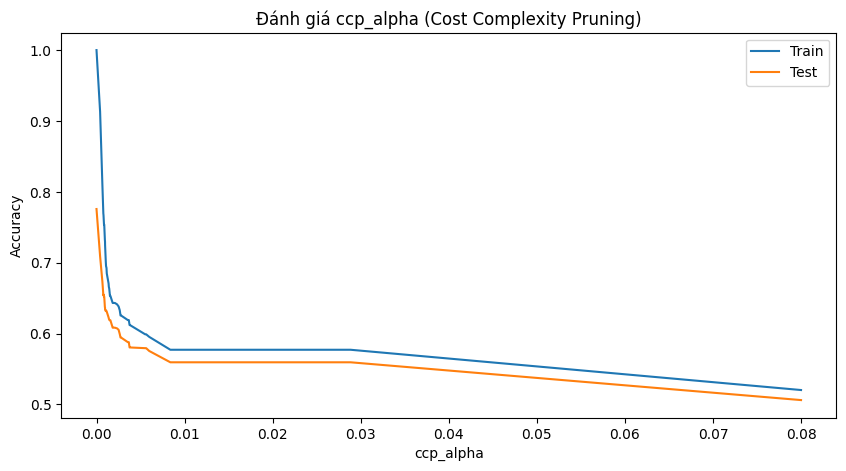

In [34]:

plt.figure(figsize=(10,5))
plt.plot(ccp_alphas, train_scores, label="Train")
plt.plot(ccp_alphas, test_scores, label="Test")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Đánh giá ccp_alpha (Cost Complexity Pruning)")
plt.show()


In [35]:
for a, tr, te in zip(ccp_alphas, train_scores, test_scores):
    print(f"alpha={a:.4f} | Train={tr:.4f} | Test={te:.4f}")


alpha=0.0000 | Train=1.0000 | Test=0.7758
alpha=0.0004 | Train=0.9131 | Test=0.7090
alpha=0.0007 | Train=0.8094 | Test=0.6731
alpha=0.0008 | Train=0.7695 | Test=0.6542
alpha=0.0008 | Train=0.7671 | Test=0.6552
alpha=0.0008 | Train=0.7539 | Test=0.6522
alpha=0.0009 | Train=0.7539 | Test=0.6522
alpha=0.0009 | Train=0.7539 | Test=0.6522
alpha=0.0009 | Train=0.7539 | Test=0.6522
alpha=0.0010 | Train=0.7321 | Test=0.6373
alpha=0.0010 | Train=0.7295 | Test=0.6368
alpha=0.0010 | Train=0.7248 | Test=0.6338
alpha=0.0011 | Train=0.7016 | Test=0.6318
alpha=0.0011 | Train=0.6954 | Test=0.6328
alpha=0.0011 | Train=0.6926 | Test=0.6318
alpha=0.0012 | Train=0.6849 | Test=0.6308
alpha=0.0014 | Train=0.6708 | Test=0.6228
alpha=0.0014 | Train=0.6661 | Test=0.6213
alpha=0.0014 | Train=0.6633 | Test=0.6193
alpha=0.0015 | Train=0.6533 | Test=0.6188
alpha=0.0015 | Train=0.6533 | Test=0.6188
alpha=0.0016 | Train=0.6533 | Test=0.6188
alpha=0.0018 | Train=0.6432 | Test=0.6084
alpha=0.0019 | Train=0.6432 | Test

In [36]:
pruned_model = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=0.3301,     # giá trị tìm được từ biểu đồ
    random_state=42
)

pruned_model.fit(X_train, y_train)

y_pred2 = pruned_model.predict(X_test)
print("Sau khi tỉa:", pruned_model.score(X_test, y_test))


Sau khi tỉa: 0.3398106626806178


In [37]:
# BIẾN MỤC TIÊU CÂN BẰNG

q60 = df_clf['realSum'].quantile(0.6)

# Hàm phân loại
def classify_price(x):
    if x <= q60:
        return 'Thấp'
    else:
        return 'Cao'

df_clf['price_group'] = df_clf['realSum'].apply(classify_price)
df_clf

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,lng,lat,weekends,price_group
0,296.159940,1.0,False,True,2.0,True,0,0,10.0,97.0,1,0.699821,0.193709,518.478947,1218.662228,2.35385,48.86282,0,Thấp
1,288.237487,1.0,False,True,2.0,True,0,0,10.0,97.0,1,2.100005,0.107221,873.216962,1000.543327,2.32436,48.85902,0,Thấp
2,211.343089,1.0,False,True,2.0,False,0,0,10.0,94.0,1,3.302325,0.234724,444.556077,902.854467,2.31714,48.87475,0,Thấp
3,298.956100,0.0,False,False,2.0,False,0,1,9.0,91.0,1,0.547567,0.195997,542.142014,1199.184166,2.35600,48.86100,0,Thấp
4,247.926181,0.0,False,False,4.0,False,0,0,7.0,82.0,1,1.197921,0.103573,406.928958,1070.775497,2.35915,48.86648,0,Thấp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,295.460900,0.0,False,False,4.0,False,0,0,9.0,80.0,1,3.660389,0.168146,209.752453,540.326583,2.38051,48.88393,1,Thấp
3554,232.081275,0.0,False,False,4.0,False,0,0,10.0,98.0,1,3.558813,0.154703,185.486701,474.351813,2.40050,48.85093,1,Thấp
3555,223.925809,0.0,False,False,2.0,False,1,0,9.0,89.0,1,4.205205,0.253029,172.658919,406.585935,2.40100,48.87700,1,Thấp
3556,200.857489,0.0,False,False,2.0,True,0,0,9.0,93.0,1,2.891214,0.240674,235.167925,602.451672,2.38200,48.87400,1,Thấp


In [41]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

alpha_scores = []
for a in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    scores = cross_val_score(dt, X_train, y_train, cv=skf, scoring='accuracy')
    alpha_scores.append((a, scores.mean(), scores.std()))

# chọn alpha có mean cao nhất (và std nhỏ)
best_alpha, best_mean, best_std = max(alpha_scores, key=lambda x: (x[1], -x[2]))
print("Best alpha:", best_alpha, best_mean, best_std)


Best alpha: 0.0 1.0 0.0


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'ccp_alpha': ccp_alphas,
    'max_depth': [None, 5, 8, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
gs = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_, "Best cv score:", gs.best_score_)
best_dt = gs.best_estimator_


Best params: {'ccp_alpha': np.float64(0.0), 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2} Best cv score: 1.0


In [294]:
df_clf = df_clf.drop('realSum', axis=1)

In [295]:
# LOẠI 1 BIẾN TRONG CẶP BIẾN CÓ TƯƠNG QUAN CAO BẰNG IMPORTANCE

df_clf = df_clf.drop('rest_index', axis=1)

In [296]:
df_clf.shape

(6683, 17)

#### Hồi quy

In [464]:
df_reg = df.copy()

In [465]:
# CHUYỂN VỀ LOG CHO ĐỠ LỆCH

df_reg['realSum'] = np.log1p(df_reg['realSum'])
df_reg['guest_satisfaction_overall'] = np.log1p(df_reg['guest_satisfaction_overall'])


<Axes: >

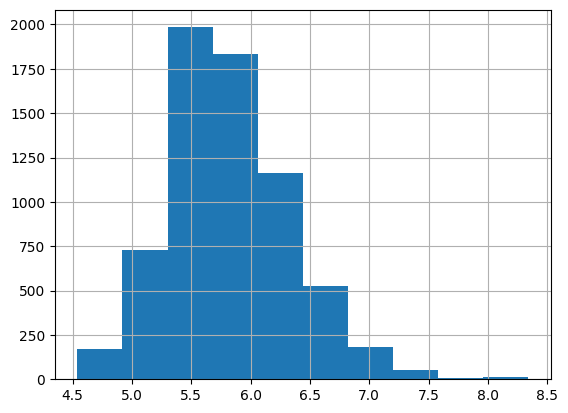

In [504]:
df_reg['realSum'].hist()

<Axes: ylabel='realSum'>

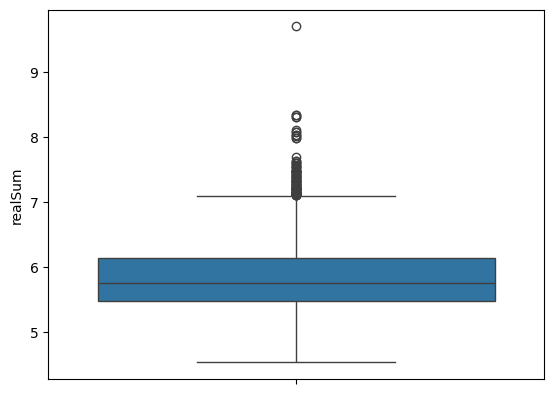

In [466]:
sns.boxplot(df_reg['realSum'])

<Axes: ylabel='realSum'>

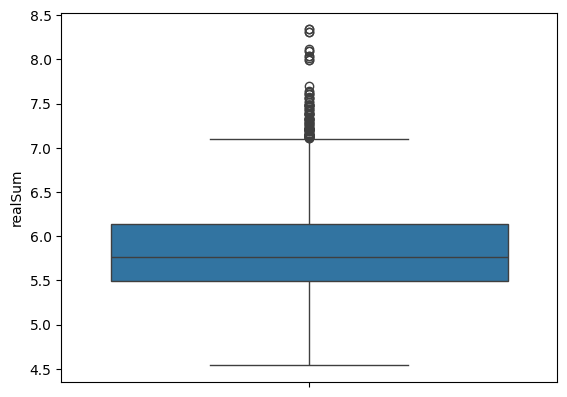

In [467]:
# LOẠI OUTLIER HIẾM

df_reg= df_reg.loc[df_reg['realSum'] <= 9, :]
sns.boxplot(df_reg['realSum'])

<Axes: ylabel='guest_satisfaction_overall'>

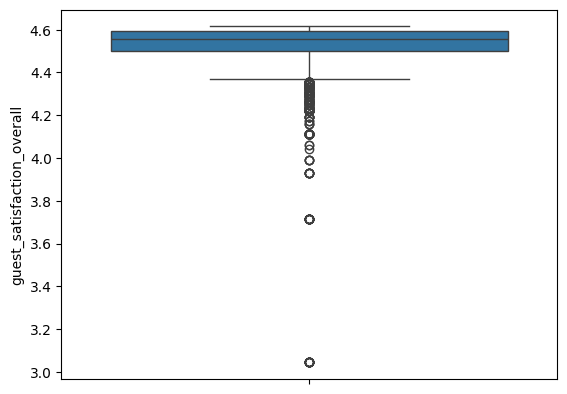

In [468]:
sns.boxplot(df_reg['guest_satisfaction_overall'])

<Axes: ylabel='guest_satisfaction_overall'>

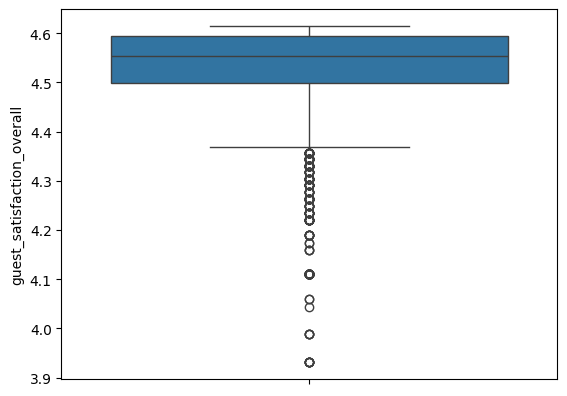

In [469]:
# LOẠI OUTLIER HIẾM

df_reg= df_reg.loc[df_reg['guest_satisfaction_overall'] >= 3.8, :]
sns.boxplot(df_reg['guest_satisfaction_overall'])

In [470]:
# LOẠI 1 BIẾN TRONG CẶP BIẾN CÓ TƯƠNG QUAN CAO BẰNG IMPORTANCE

df_reg = df_reg.drop('rest_index', axis=1)

In [471]:
df_reg.shape

(6656, 17)

### SCALING

#### Phân lớp

In [364]:
encoder_1 = LabelEncoder()
df_clf['room_type'] =  encoder_1.fit_transform(df_clf['room_type'])

encoder_2 = OrdinalEncoder()
df_clf['price_group'] =  encoder_1.fit_transform(df_clf['price_group'])

#### Hồi quy

In [365]:
encoder_1 = LabelEncoder()
df_reg['room_type'] =  encoder_1.fit_transform(df_reg['room_type'])

### CLASSIFICATION

In [298]:
X = df_clf.drop('price_group', axis=1, inplace=False)
y = df_clf['price_group']

In [299]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=81)

In [300]:
clf = DecisionTreeClassifier(criterion='gini', max_depth= 5, random_state=81)
clf_model = clf.fit(X_train, y_train)


(process:12884): Pango-CRITICAL **: 18:41:32.999: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:12884): Pango-CRITICAL **: 18:41:32.999: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:12884): Pango-CRITICAL **: 18:41:32.999: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:12884): Pango-CRITICAL **: 18:41:32.999: pango_font_description_get_family: assertion 'desc != NULL' failed



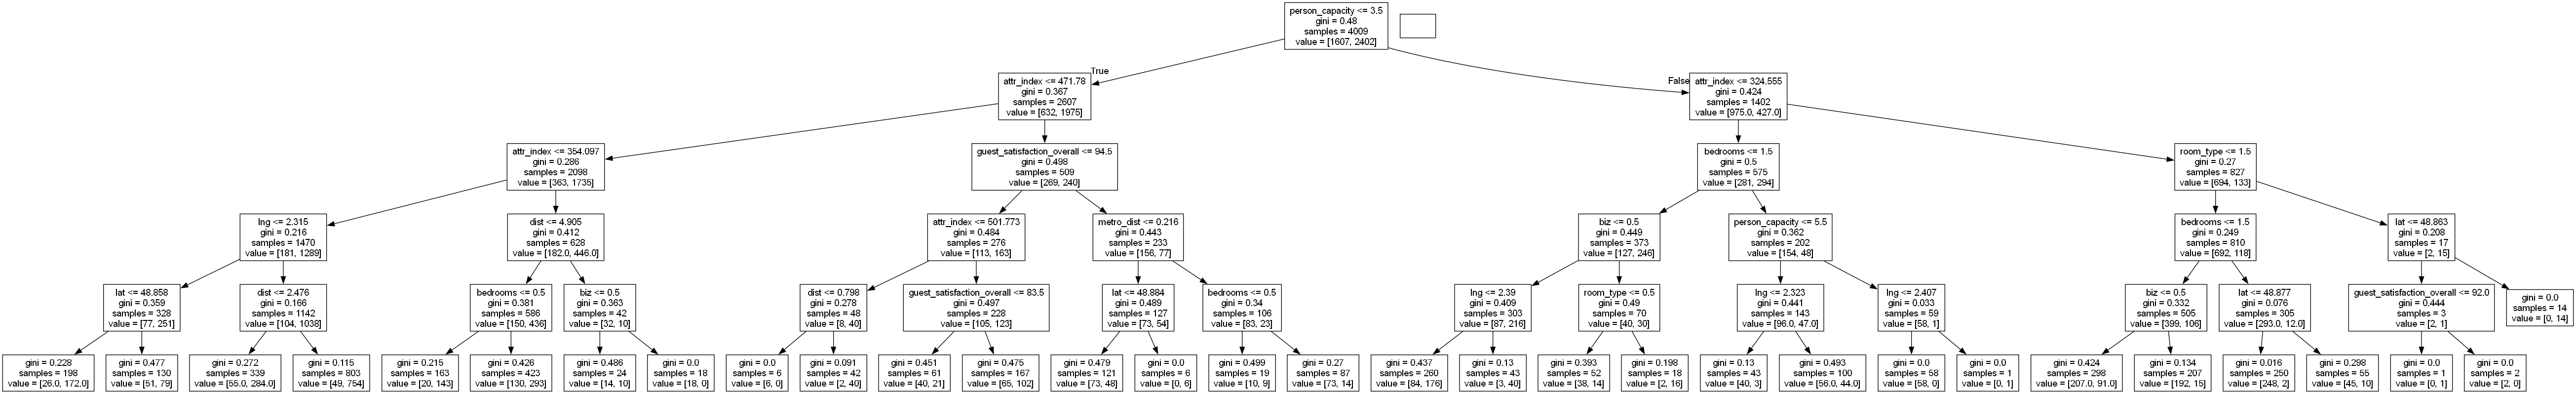

In [301]:
dcs_tree = tree.export_graphviz(clf, out_file = None, feature_names = X.columns)
graph    = pdp.graph_from_dot_data(dcs_tree)
Image(graph.create_png())

In [302]:
def classification_eval(y_test, y_pred):
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score(y_test, y_pred, average='macro')
    f1        = f1_score(y_test, y_pred, average='macro')
    return accuracy, precision, recall, f1

In [303]:
y_pred_test = clf_model.predict(X_test)
y_pred_train = clf_model.predict(X_train)

scores_test = classification_eval(y_test, y_pred_test)
score_train = classification_eval(y_train, y_pred_train)


print('===== TEST =====')
print(f'accuracy   = {(scores_test[0] * 100):.1f}%')
print(f'precision = {(scores_test[1] * 100):.1f}%')
print(f'recall    = {(scores_test[2] * 100):.1f}%')
print(f'f1        = {(scores_test[3] * 100):.1f}%')

print('===== TRAIN =====')
print(f'accuracy   = {(score_train[0] * 100):.1f}%')
print(f'precision = {(score_train[1] * 100):.1f}%')
print(f'recall    = {(score_train[2] * 100):.1f}%')
print(f'f1        = {(score_train[3] * 100):.1f}%')

===== TEST =====
accuracy   = 79.4%
precision = 78.8%
recall    = 77.8%
f1        = 78.2%
===== TRAIN =====
accuracy   = 80.8%
precision = 80.6%
recall    = 79.0%
f1        = 79.6%


#### Chỉnh siêu tham số

In [304]:
results = []
for depth in range(1, 30):  
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc, prec, rec, f1 = classification_eval(y_pred, y_test)
    results.append({
        'depth': depth,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

results_test_df = pd.DataFrame(results)

In [305]:
results = []
for depth in range(1, 30):  
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_train)

    acc, prec, rec, f1 = classification_eval(y_pred, y_train)
    results.append({
        'depth': depth,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

results_train_df = pd.DataFrame(results)

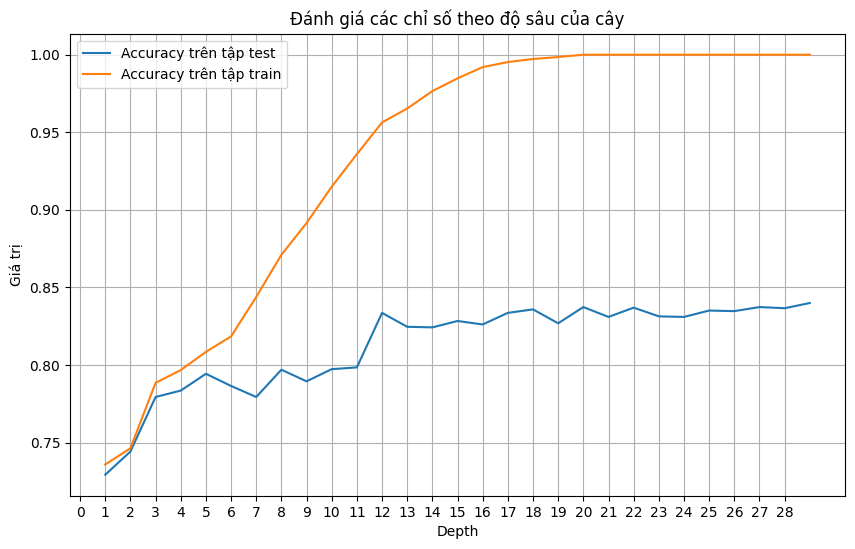

In [306]:
plt.figure(figsize=(10,6))
plt.plot(results_test_df['depth'], results_test_df['accuracy'], label='Accuracy trên tập test')
plt.plot(results_train_df['depth'], results_train_df['accuracy'], label='Accuracy trên tập train')

"""plt.plot(results_df['depth'], results_df['precision'], label='Precision')
plt.plot(results_df['depth'], results_df['recall'], label='Recall')
plt.plot(results_df['depth'], results_df['f1'], label='F1-score')"""

plt.xlabel('Depth')
plt.ylabel('Giá trị')
plt.xticks(np.arange(depth))
plt.title('Đánh giá các chỉ số theo độ sâu của cây')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
"""model = DecisionTreeClassifier()

param_distributions = {
    'criterion': ['gini'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 20, 50, 100, 200],
    'ccp_alpha': np.linspace(0.0, 0.05, 5)
}
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=500,           # số tổ hợp được thử
    scoring='accuracy',  # tiêu chí đánh giá
    cv=10,                # k-fold cross-validation
    verbose=2,           # hiển thị tiến trình
    random_state=81,
    n_jobs=-1            # tận dụng toàn bộ CPU
)

random_search.fit(X_train, y_train)


print("Best parameters found:")
print(random_search.best_params_)
print(f"Best cross-validation accuracy: {random_search.best_score_:.2f}")

# Đánh giá trên tập test
best_model = random_search.best_estimator_
y_pred_test = best_model.predict(X_test)

print("\nTest set performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.2f}")
print(classification_report(y_test, y_pred_test))

# Đánh giá trên tập train
best_model = random_search.best_estimator_
y_pred_train = best_model.predict(X_train)

print("\Train set performance:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.2f}")
print(classification_report(y_train, y_pred_train))"""

Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Best parameters found:
{'splitter': 'best', 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_leaf_nodes': 200, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'ccp_alpha': np.float64(0.0)}
Best cross-validation accuracy: 0.80

Test set performance:
Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1066
           1       0.83      0.84      0.84      1608

    accuracy                           0.80      2674
   macro avg       0.80      0.79      0.80      2674
weighted avg       0.80      0.80      0.80      2674

\Train set performance:
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1607
           1       0.93      0.93      0.93      2402

    accuracy                           0.91      4009
   macro avg       0.91      0.91      0.91      4009
weighted avg      

In [308]:
params = []
acc = []
for i in range(1, 6):
    model = DecisionTreeClassifier()

    param_distributions = {
    'criterion': ['gini'],
    'splitter': ['best'],
    'max_depth': [i for i in range(12, 24, 2)],
    'min_samples_split': [2, 3, 4, 5, 6],
    'min_samples_leaf': [2, 3, 4, 5, 6],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [i for i in range(40, 120, 20)],
    'ccp_alpha': np.linspace(0.0, 0.005, 5)
    }
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=1000,           # chỉ thử ngẫu nhiên 80 tổ hợp
        scoring='accuracy',  # tiêu chí đánh giá
        cv=5,                # k-fold cross-validation
        verbose=2,           # hiển thị tiến trình
        random_state=81,
        n_jobs=-1            # tận dụng toàn bộ CPU
    )

    random_search.fit(X_train, y_train)
    # Lưu các params
    params.append(random_search.best_params_)

    # Đánh giá trên tập test
    best_model = random_search.best_estimator_
    y_pred_test = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Đánh giá trên tập train
    best_model = random_search.best_estimator_
    y_pred_train = best_model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)

    acc.append({'test_acc': test_acc, 'train_acc': train_acc})

params_df = pd.DataFrame(params)
acc_df = pd.DataFrame(acc)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


In [309]:
r = [params_df, acc_df]
result_df = pd.concat(r, axis= 1)
result_df['test_train_diff'] = result_df['train_acc'] - result_df['test_acc']
result_df

,splitter,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,criterion,ccp_alpha,test_acc,train_acc,test_train_diff
0,best,5,3,80,sqrt,14,gini,0.0,0.789828,0.831629,0.041801
1,best,6,5,100,sqrt,14,gini,0.0,0.769634,0.833125,0.063492
2,best,4,6,100,log2,12,gini,0.0,0.764024,0.818907,0.054884
3,best,2,3,60,sqrt,14,gini,0.0,0.786836,0.815665,0.028829
4,best,3,2,80,sqrt,18,gini,0.0,0.789828,0.842854,0.053026


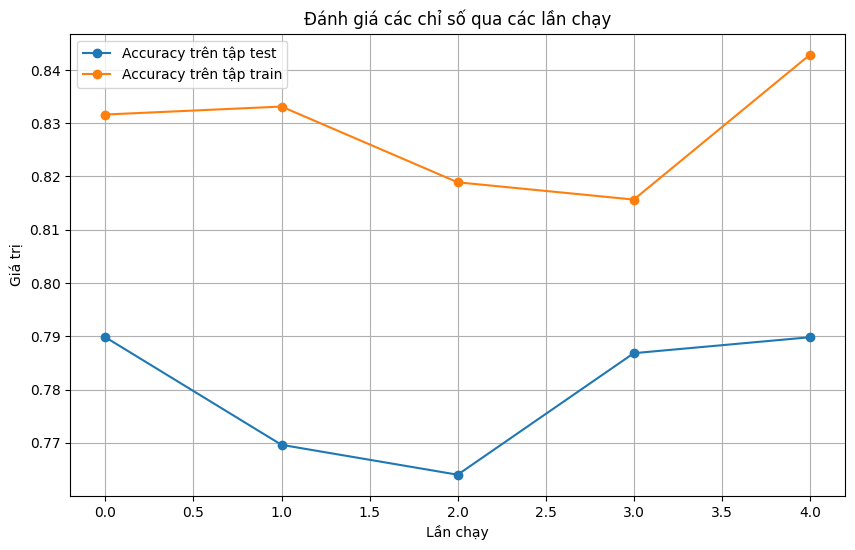

In [310]:
plt.figure(figsize=(10,6))
plt.plot(result_df.index, result_df['test_acc'], label='Accuracy trên tập test', marker= 'o')
plt.plot(result_df.index, result_df['train_acc'], label='Accuracy trên tập train', marker='o')

"""plt.plot(results_df['depth'], results_df['precision'], label='Precision')
plt.plot(results_df['depth'], results_df['recall'], label='Recall')
plt.plot(results_df['depth'], results_df['f1'], label='F1-score')"""

plt.xlabel('Lần chạy')
plt.ylabel('Giá trị')
plt.title('Đánh giá các chỉ số qua các lần chạy')
plt.legend()
plt.grid(True)
plt.show()

### REGRESSION

In [472]:
X = df_reg.drop('realSum', axis=1, inplace=False)
y = df_reg['realSum']

In [473]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=81)

In [474]:
reg = DecisionTreeRegressor(criterion='squared_error', max_depth= 5)
reg_model = reg.fit(X_train, y_train)

In [475]:
def regression_eval(y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    return mae, mse

In [476]:
y_pred = reg_model.predict(X_test)
errors   = regression_eval(y_test, y_pred)
r2_total = reg_model.score(X, y)
r2_train = reg_model.score(pd.DataFrame(X_train), y_train)
r2_test  = reg_model.score(pd.DataFrame(X_test),  y_test)

## Hiển thị giá trị các chỉ số
print(f'MAE = {errors[0]:.1f}%')
print(f'MSE = {errors[1]:.1f}%')
print(f'Mô hình giải thích được {(r2_total * 100):.1f}% toàn bộ dữ liệu')
print(f'Mô hình giải thích được {(r2_train * 100):.1f}% training set')
print(f'Mô hình  giải thích được {(r2_test  * 100):.1f}% test set')

MAE = 0.3%
MSE = 0.1%
Mô hình giải thích được 56.9% toàn bộ dữ liệu
Mô hình giải thích được 57.2% training set
Mô hình  giải thích được 55.8% test set


In [477]:
result = []
for depth in range(1, 10):
    reg = DecisionTreeRegressor(criterion='squared_error', max_depth= depth)
    reg_model = reg.fit(X_train, y_train)

    y_pred = reg_model.predict(X_test)
    errors   = regression_eval(y_test, y_pred)
    r2_total = reg_model.score(X, y)
    r2_train = reg_model.score(pd.DataFrame(X_train), y_train)
    r2_test  = reg_model.score(pd.DataFrame(X_test),  y_test)
    result.append({
        'depth': depth,
        'r2_total': r2_total,
        'r2_train': r2_train,
        'r2_test': r2_test
    })
result_df = pd.DataFrame(result)
result_df


,depth,r2_total,r2_train,r2_test
0,1,0.227986,0.233481,0.205637
1,2,0.368676,0.369644,0.364650
2,3,0.461118,0.462350,0.456045
3,4,0.527472,0.526730,0.530390
4,5,0.568971,0.571558,0.558436
5,6,0.607493,0.616367,0.571552
6,7,0.648012,0.663149,0.586760
7,8,0.690398,0.713041,0.598806
8,9,0.736014,0.764560,0.620566


r2_total
r2_train
r2_test


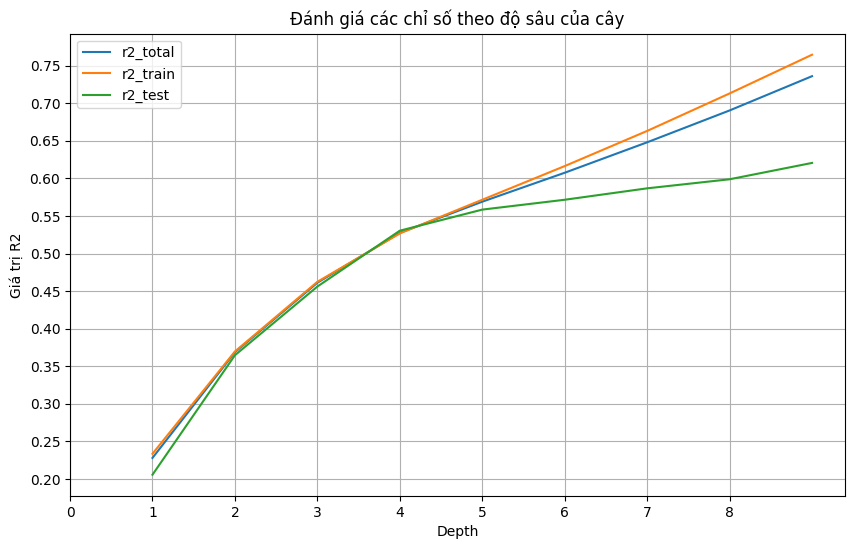

In [478]:
plt.figure(figsize= (10, 6))
for i in range(1, len(result_df.columns)):
    print(result_df.columns[i])
    plt.plot(result_df['depth'], result_df.iloc[:, i], label= result_df.columns[i])

plt.xlabel('Depth')
plt.ylabel('Giá trị R2')
plt.xticks(np.arange(depth))
plt.locator_params(axis='y', nbins=20)
plt.title('Đánh giá các chỉ số theo độ sâu của cây')
plt.legend()
plt.grid(True)
plt.show()

In [500]:
from sklearn.metrics import r2_score

params = []
acc = []

for i in range(1, 6):
    model = DecisionTreeRegressor()

    param_distributions = {
    'criterion': ['squared_error'],
    'splitter': ['best'],
    'max_depth': [i for i in range(10, 20, 1)], 
    'min_samples_split': [i for i in range(30, 80, 10)],          
    'min_samples_leaf': [i for i in range(5, 100, 5)],        # Tăng giá trị này → mượt hơn, ít overfit
    'max_features': [None, 'sqrt', 'log2'],             
    'max_leaf_nodes': [i for i in range(80, 140, 10)],     
    'ccp_alpha': np.linspace(0.0, 1, 10)             
    }


    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=500,            
        scoring='r2',
        cv=5,
        verbose=2,
        random_state=81,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    params.append(random_search.best_params_)

    best_model = random_search.best_estimator_
    y_pred_test = best_model.predict(X_test)
    y_pred_train = best_model.predict(X_train)

    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse  = mean_squared_error(y_test, y_pred_test)

    acc.append({
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mse': train_mse,
        'test_mse': test_mse
    })
    
params_df = pd.DataFrame(params)
acc_df = pd.DataFrame(acc)


Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [502]:
r = [params_df, acc_df]
result_df = pd.concat(r, axis= 1)
result_df['test_train_diff'] = result_df['train_r2'] - result_df['test_r2']
result_df

,splitter,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,criterion,ccp_alpha,train_r2,test_r2,train_mse,test_mse,test_train_diff
0,best,30,5,130,None,13,squared_error,0.0,0.695476,0.587996,0.078331,0.10478,0.10748
1,best,30,5,130,None,13,squared_error,0.0,0.695476,0.587996,0.078331,0.10478,0.10748
2,best,30,5,130,None,13,squared_error,0.0,0.695476,0.587996,0.078331,0.10478,0.10748
3,best,30,5,130,None,13,squared_error,0.0,0.695476,0.587996,0.078331,0.10478,0.10748
4,best,30,5,130,None,13,squared_error,0.0,0.695476,0.587996,0.078331,0.10478,0.10748


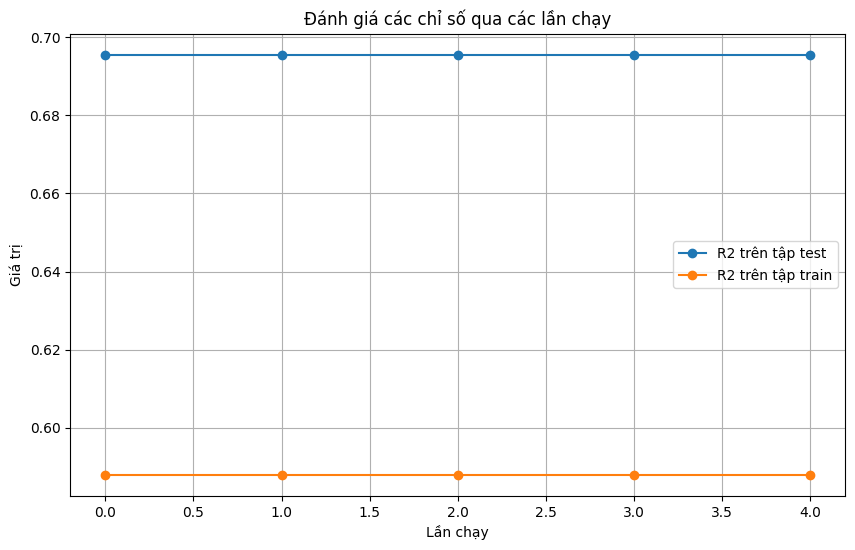

In [503]:
plt.figure(figsize=(10,6))
plt.plot(result_df.index, result_df['train_r2'], label='R2 trên tập test', marker= 'o')
plt.plot(result_df.index, result_df['test_r2'], label='R2 trên tập train', marker='o')

"""plt.plot(results_df['depth'], results_df['precision'], label='Precision')
plt.plot(results_df['depth'], results_df['recall'], label='Recall')
plt.plot(results_df['depth'], results_df['f1'], label='F1-score')"""

plt.xlabel('Lần chạy')
plt.ylabel('Giá trị')
plt.title('Đánh giá các chỉ số qua các lần chạy')
plt.legend()
plt.grid(True)
plt.show()